# Exploración Inicial de Datos (EDA) — Tendencias de YouTube (EE. UU.)

Notebook de **exploración pre-limpieza**. Su objetivo es diagnosticar la calidad y la
estructura del dataset `USvideos_cc50_202101.csv` **antes** de aplicar cualquier
limpieza o transformación, para tomar decisiones informadas en la siguiente fase.

Complementa la exploración básica del notebook principal
(`upc_2026_01_seccion_NRC_grupo4_tf.ipynb`) añadiendo: cardinalidad y tipos,
asimetría/curtosis, visualización de nulos, duplicados (a distintos niveles),
distribuciones y outliers por IQR, correlaciones, análisis temporal y la validación
de las reglas de negocio esbozadas en `scripts/eda.py`.

> Este notebook **no modifica** los datos: solo observa y resume hallazgos.

## Índice
1. Setup y carga de datos
2. Panorama general y tipos de datos
3. Estadísticos descriptivos (asimetría/curtosis)
4. Valores nulos
5. Duplicados
6. Distribuciones y outliers
7. Correlaciones
8. Temporalidad
9. Validación de reglas de negocio
10. Resumen de hallazgos para la limpieza

## 1. Setup y carga de datos

Importamos librerías, configuramos el estilo de los gráficos y cargamos el CSV.
La ruta se resuelve automáticamente buscando la carpeta `dataset/` desde la raíz del
repositorio, de modo que el notebook funcione tanto ejecutándose desde `notebooks/`
como desde la raíz. También cruzamos con `US_category_id.json` para obtener
`category_name`.

In [73]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("ggplot")
sns.set_palette("husl")
%matplotlib inline

# Resolver la raiz del repositorio buscando la carpeta 'dataset/'
ROOT = Path.cwd()
while not (ROOT / "dataset").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CSV_PATH = ROOT / "dataset" / "USvideos_cc50_202101.csv"
JSON_PATH = ROOT / "dataset" / "US_category_id.json"
print("Raiz del repo:", ROOT)
print("CSV:", CSV_PATH.exists(), "| JSON:", JSON_PATH.exists())

Raiz del repo: d:\UPChexk\2026-I\Fundamentos_Data_Science\TFF\1ACC0216-TB2-2026-1
CSV: True | JSON: True


In [74]:
# Carga del dataset
df = pd.read_csv(CSV_PATH)

# Cruce con el catalogo de categorias (JSON con estructura de la API de YouTube)
with open(JSON_PATH, "r", encoding="utf-8") as f:
    categories_data = json.load(f)

category_mapping = {
    int(item["id"]): item["snippet"]["title"] for item in categories_data["items"]
}
df["category_name"] = df["category_id"].map(category_mapping)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 40,949 | Columnas: 21


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,Utah,39.419220,-111.950684,POINT (-111.950684 39.41922),People & Blogs
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",Nevada,39.876019,-117.224121,POINT (-117.224121 39.876019),Entertainment
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Comedy
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,Delaware,39.000000,-75.500000,POINT (-75.5 39),Entertainment
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Entertainment


## 2. Panorama general y tipos de datos

Dimensiones, tipos, uso de memoria y una muestra aleatoria. Después revisamos la
**cardinalidad** (número de valores únicos) para clasificar cada columna en numérica,
categórica, booleana o temporal, lo que guía el tratamiento posterior.

In [75]:
# Estructura general y tipos
print("Dimensiones (filas, columnas):", df.shape)
print(f"Uso de memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB\n")
df.info()

Dimensiones (filas, columnas): (40949, 21)
Uso de memoria: 117.7 MB

<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                40949 non-null  str    
 1   trending_date           40949 non-null  str    
 2   title                   40949 non-null  str    
 3   channel_title           40949 non-null  str    
 4   category_id             40949 non-null  int64  
 5   publish_time            40949 non-null  str    
 6   tags                    40949 non-null  str    
 7   views                   40949 non-null  int64  
 8   likes                   40949 non-null  int64  
 9   dislikes                40949 non-null  int64  
 10  comment_count           40949 non-null  int64  
 11  thumbnail_link          40949 non-null  str    
 12  comments_disabled       40949 non-null  bool   
 13  ratings_disabled        40949 non

In [76]:
# Muestra aleatoria para inspeccion cualitativa
df.sample(5, random_state=42)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
15632,ugdgAifIOBA,18.02.02,Why Don't We - Trust Fund Baby (Official Audio),Atlantic Records,10,2018-02-01T05:01:03.000Z,"music|""official""|""music video""|""atlantic""|""rec...",206028,21951,329,2951,https://i.ytimg.com/vi/ugdgAifIOBA/default.jpg,False,False,False,'Trust Fund Baby' Out Now:\nhttps://Atlantic.l...,Wisconsin,44.500000,-89.500000,POINT (-89.5 44.5),Music
40759,Gi56dSh8Fq8,18.14.06,Gourmet Chef Makes A Big Mac Super Fancy,BuzzFeedVideo,22,2018-06-13T18:00:32.000Z,"mcdonalds|""big mac""|""fancy""|""fast food""|""jacqu...",402418,10070,3303,2142,https://i.ytimg.com/vi/Gi56dSh8Fq8/default.jpg,False,False,False,"It's your good ol' McDonald's Big Mac, but lik...",Ohio,40.367474,-82.996216,POINT (-82.996216 40.367474),People & Blogs
10536,7VnEPIBsp20,18.05.01,Zac Efron Made Michael Jackson Cry! | The Grah...,The Graham Norton Show,24,2017-12-29T15:30:01.000Z,"Graham Norton|""Graham Norton Show Official""|""E...",1437372,33670,1626,2233,https://i.ytimg.com/vi/7VnEPIBsp20/default.jpg,False,False,False,Dreams do come true...\nSubscribe for weekly u...,Nebraska,41.500000,-100.000000,POINT (-100 41.5),Entertainment
11029,vvuj7-xspns,18.08.01,JuJu Smith-Schuster Pranks Steelers Fans - Und...,JuJu Smith-Schuster,24,2018-01-05T18:59:22.000Z,"JuJu Smith-Schuster|""JuJu Smith""|""JuJu""|""JuJu ...",417790,13878,346,2000,https://i.ytimg.com/vi/vvuj7-xspns/default.jpg,False,False,False,I took over the streets as John Smith from WXW...,Texas,31.000000,-100.000000,POINT (-100 31),Entertainment
8202,0ycLaWymtKk,17.25.12,Merry Christmas in Dominoes! 🎅🏻 (Christmas Card),Hevesh5,24,2017-12-23T18:00:00.000Z,"christmas|""christmas domino""|""merry christmas""...",816662,16873,468,1038,https://i.ytimg.com/vi/0ycLaWymtKk/default.jpg,False,False,False,Merry Christmas! Share this Christmas card wit...,Arizona,34.048927,-111.093735,POINT (-111.093735 34.048927),Entertainment


In [77]:
# Cardinalidad y resumen por columna
resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(dropna=True),
    "%_unicos": (df.nunique(dropna=True) / len(df) * 100).round(2),
    "n_nulos": df.isnull().sum(),
    "ejemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
resumen.sort_values("n_unicos", ascending=False)

,dtype,n_unicos,%_unicos,n_nulos,ejemplo
views,int64,40478,98.85,0,748374
likes,int64,29850,72.90,0,57527
comment_count,int64,13773,33.63,0,15954
dislikes,int64,8516,20.80,0,2966
description,str,6901,16.85,570,SHANTELL'S CHANNEL - https://www.youtube.com/s...
title,str,6455,15.76,0,WE WANT TO TALK ABOUT OUR MARRIAGE
thumbnail_link,str,6352,15.51,0,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg
video_id,str,6351,15.51,0,2kyS6SvSYSE
publish_time,str,6269,15.31,0,2017-11-13T17:13:01.000Z
tags,str,6055,14.79,0,SHANtell martin


In [78]:
# Clasificacion de columnas por naturaleza (guia para la limpieza)
num_cols = ["views", "likes", "dislikes", "comment_count"]
cat_cols = ["category_name", "channel_title", "state", "category_id"]
bool_cols = ["comments_disabled", "ratings_disabled", "video_error_or_removed"]
date_cols = ["trending_date", "publish_time"]
geo_cols = ["lat", "lon", "geometry"]

print("Numericas :", num_cols)
print("Categoricas:", cat_cols)
print("Booleanas :", bool_cols)
print("Fechas    :", date_cols)
print("Geograficas:", geo_cols)

Numericas : ['views', 'likes', 'dislikes', 'comment_count']
Categoricas: ['category_name', 'channel_title', 'state', 'category_id']
Booleanas : ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']
Fechas    : ['trending_date', 'publish_time']
Geograficas: ['lat', 'lon', 'geometry']


## 3. Estadísticos descriptivos

Estadísticas de las variables numéricas y categóricas. Calculamos además la
**asimetría (skewness)** y la **curtosis** de las métricas de engagement: un sesgo
alto a la derecha justifica el uso de transformaciones logarítmicas (`log1p`) en el
modelado posterior.

In [79]:
# Estadisticos de variables numericas
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
views,40949.0,2.360785e+06,7.394114e+06,549.0,242329.0,681861.0,1823157.0,225211923.0
likes,40949.0,7.426670e+04,2.288853e+05,0.0,5424.0,18091.0,55417.0,5613827.0
dislikes,40949.0,3.711401e+03,2.902971e+04,0.0,202.0,631.0,1938.0,1674420.0
comment_count,40949.0,8.446804e+03,3.743049e+04,0.0,614.0,1856.0,5755.0,1361580.0


In [80]:
# Estadisticos de variables categoricas / texto
df.describe(include="object").T

C:\Users\sergi\AppData\Local\Temp\ipykernel_43404\686101941.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
video_id,40949,6351,j4KvrAUjn6c,30
trending_date,40949,205,17.14.11,200
title,40949,6455,WE MADE OUR MOM CRY...HER DREAM CAME TRUE!,30
channel_title,40949,2207,ESPN,203
publish_time,40949,6269,2018-05-18T14:00:04.000Z,50
tags,40949,6055,[none],1535
thumbnail_link,40949,6352,https://i.ytimg.com/vi/j4KvrAUjn6c/default.jpg,30
description,40379,6901,► Listen LIVE: http://power1051fm.com/\n► Face...,58
state,40949,50,North Carolina,888
geometry,40949,50,POINT (-80.793457 35.782169),888


In [81]:
# Asimetria y curtosis: cuantifican el sesgo de las metricas de engagement
forma = pd.DataFrame({
    "asimetria_skew": df[num_cols].skew(),
    "curtosis_kurt": df[num_cols].kurt(),
})
forma["interpretacion"] = np.where(
    forma["asimetria_skew"].abs() > 1, "muy sesgada (considerar log)",
    np.where(forma["asimetria_skew"].abs() > 0.5, "moderadamente sesgada", "aprox. simetrica"),
)
forma

,asimetria_skew,curtosis_kurt,interpretacion
views,12.240171,232.380254,muy sesgada (considerar log)
likes,10.923768,177.847084,muy sesgada (considerar log)
dislikes,40.189278,1987.423271,muy sesgada (considerar log)
comment_count,19.754566,532.144184,muy sesgada (considerar log)


## 4. Valores nulos

Cantidad y porcentaje de nulos por columna, con una visualización para identificar
rápidamente qué campos requieren tratamiento (imputación o eliminación).

In [82]:
# Tabla de nulos: cantidad y porcentaje
nulos = df.isnull().sum()
tabla_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "%_nulos": (nulos / len(df) * 100).round(2),
}).sort_values("n_nulos", ascending=False)
tabla_nulos[tabla_nulos["n_nulos"] > 0]

,n_nulos,%_nulos
description,570,1.39


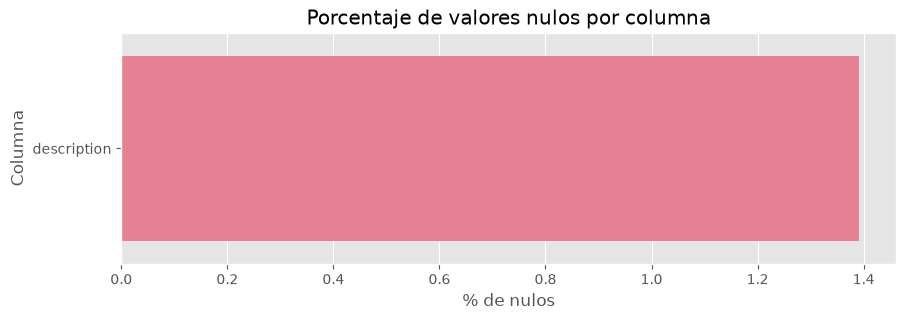

In [83]:
# Visualizacion del porcentaje de nulos por columna
pct = (df.isnull().mean() * 100).sort_values(ascending=False)
pct = pct[pct > 0]

if len(pct) > 0:
    plt.figure(figsize=(10, max(3, 0.4 * len(pct))))
    sns.barplot(x=pct.values, y=pct.index)
    plt.title("Porcentaje de valores nulos por columna")
    plt.xlabel("% de nulos")
    plt.ylabel("Columna")
    plt.show()
else:
    print("No hay columnas con valores nulos.")

## 5. Duplicados

Analizamos duplicados a tres niveles. **Nota:** el notebook principal usa
`df[df.duplicated]` (sin paréntesis), lo que es un error; aquí usamos
`df.duplicated()` correctamente.

- **Exactos**: filas idénticas en todas las columnas (candidatas a eliminar).
- **Por `video_id`**: un mismo video puede aparecer en varios días de tendencia, así
  que no todos son errores; es esperable por la naturaleza del dataset.
- **Por `(video_id, trending_date)`**: si existen, sí serían registros redundantes del
  mismo video en el mismo día.

In [84]:
# Duplicados a distintos niveles (df.duplicated() CON parentesis)
dup_exactos = df.duplicated().sum()
dup_video = df.duplicated(subset=["video_id"]).sum()
dup_video_fecha = df.duplicated(subset=["video_id", "trending_date"]).sum()

print(f"Duplicados exactos (todas las columnas): {dup_exactos}")
print(f"Duplicados por video_id: {dup_video}  (esperable: un video en varios dias)")
print(f"Duplicados por (video_id, trending_date): {dup_video_fecha}  (redundantes reales)")

Duplicados exactos (todas las columnas): 1
Duplicados por video_id: 34598  (esperable: un video en varios dias)
Duplicados por (video_id, trending_date): 50  (redundantes reales)


In [85]:
# Ver las filas exactamente duplicadas (original + copia) si las hay
duplicados_exactos = df[df.duplicated(keep=False)]
print(f"Filas involucradas en duplicados exactos: {len(duplicados_exactos)}")
duplicados_exactos.head(10)

Filas involucradas en duplicados exactos: 2


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
34777,nRc0kmOYgzQ,18.15.05,"We built the Infinity Gauntlet with 25,000 mag...",Vat19,24,2018-05-12T11:30:03.000Z,"vat19|""vat19 nanodots""|""vat19 infinity gauntle...",2227658,29191,1157,4092,https://i.ytimg.com/vi/nRc0kmOYgzQ/default.jpg,False,False,False,"NanoDots master builder, Edo, turned a huge pi...",Louisiana,30.39183,-92.329102,POINT (-92.32910200000001 30.39183),Entertainment
34926,nRc0kmOYgzQ,18.15.05,"We built the Infinity Gauntlet with 25,000 mag...",Vat19,24,2018-05-12T11:30:03.000Z,"vat19|""vat19 nanodots""|""vat19 infinity gauntle...",2227658,29191,1157,4092,https://i.ytimg.com/vi/nRc0kmOYgzQ/default.jpg,False,False,False,"NanoDots master builder, Edo, turned a huge pi...",Louisiana,30.39183,-92.329102,POINT (-92.32910200000001 30.39183),Entertainment


In [86]:
duplicados_video_fecha = df[df.duplicated(subset=["video_id", "trending_date"], keep=False)]
print(f"Filas involucradas en duplicados por video_id y trending_date: {len(duplicados_video_fecha)}")
duplicados_video_fecha.sort_values("video_id", ascending=False).head(10)

Filas involucradas en duplicados por video_id y trending_date: 100


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,category_name
34945,zcEE8J2Bqa8,18.15.05,The Goblin - JACK AND DEAN,Jack and Dean,23,2018-05-11T18:27:01.000Z,"Jack and Dean|""OMFGItsJackAndDean""|""Jack Howar...",165617,20572,140,1407,https://i.ytimg.com/vi/zcEE8J2Bqa8/default.jpg,False,False,False,That? That's a goblin living under the stairs....,North Carolina,35.782169,-80.793457,POINT (-80.793457 35.782169),Comedy
34796,zcEE8J2Bqa8,18.15.05,The Goblin - JACK AND DEAN,Jack and Dean,23,2018-05-11T18:27:01.000Z,"Jack and Dean|""OMFGItsJackAndDean""|""Jack Howar...",165617,20572,140,1407,https://i.ytimg.com/vi/zcEE8J2Bqa8/default.jpg,False,False,False,That? That's a goblin living under the stairs....,Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Comedy
34793,y_WoOYybCro,18.15.05,How I Became The Fresh Prince of Bel-Air | STO...,Will Smith,24,2018-05-10T16:08:58.000Z,"comedy|""entertainment""|""will smith""|""will""|""sm...",2055638,120377,752,4872,https://i.ytimg.com/vi/y_WoOYybCro/default.jpg,False,False,False,"The full story of how an ex-girlfriend, Arseni...",Rhode Island,41.700001,-71.500000,POINT (-71.5 41.700001),Entertainment
34942,y_WoOYybCro,18.15.05,How I Became The Fresh Prince of Bel-Air | STO...,Will Smith,24,2018-05-10T16:08:58.000Z,"comedy|""entertainment""|""will smith""|""will""|""sm...",2055638,120377,752,4872,https://i.ytimg.com/vi/y_WoOYybCro/default.jpg,False,False,False,"The full story of how an ex-girlfriend, Arseni...",Massachusetts,42.407211,-71.382439,POINT (-71.38243900000001 42.407211),Entertainment
34903,xhs8tf1v__w,18.15.05,Terry Crews Answers the Web's Most Searched Qu...,WIRED,24,2018-05-14T16:00:29.000Z,"autocomplete|""deadpool 2""|""google autocomplete...",343967,16988,132,1308,https://i.ytimg.com/vi/xhs8tf1v__w/default.jpg,False,False,False,Terry Crews takes the WIRED Autocomplete Inter...,Hawaii,19.741755,-155.844437,POINT (-155.844437 19.741755),Entertainment
34754,xhs8tf1v__w,18.15.05,Terry Crews Answers the Web's Most Searched Qu...,WIRED,24,2018-05-14T16:00:29.000Z,"autocomplete|""deadpool 2""|""google autocomplete...",343967,16988,132,1308,https://i.ytimg.com/vi/xhs8tf1v__w/default.jpg,False,False,False,Terry Crews takes the WIRED Autocomplete Inter...,Mississippi,33.000000,-90.000000,POINT (-90 33),Entertainment
34918,xTrwT0jSUg0,18.15.05,Mother Knows Best - SNL,Saturday Night Live,24,2018-05-13T05:06:11.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""SNL...",1248343,15750,1919,1261,https://i.ytimg.com/vi/xTrwT0jSUg0/default.jpg,False,False,False,"Three mother-child pairs (Cecily Strong, Aidy ...",California,36.778259,-119.417931,POINT (-119.417931 36.778259),Entertainment
34769,xTrwT0jSUg0,18.15.05,Mother Knows Best - SNL,Saturday Night Live,24,2018-05-13T05:06:11.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""SNL...",1248343,15750,1919,1261,https://i.ytimg.com/vi/xTrwT0jSUg0/default.jpg,False,False,False,"Three mother-child pairs (Cecily Strong, Aidy ...",Michigan,44.182205,-84.506836,POINT (-84.50683600000001 44.182205),Entertainment
34790,vjSohj-Iclc,18.15.05,"Getting some air, Atlas?",BostonDynamics,28,2018-05-10T19:56:28.000Z,"Dynamic robots|""Boston Dynamics""|""humanoid rob...",5650991,76461,2666,12187,https://i.ytimg.com/vi/vjSohj-Iclc/default.jpg,False,False,False,NaN,Wisconsin,44.500000,-89.500000,POINT (-89.5 44.5),Science & Technology
34939,vjSohj-Iclc,18.15.05,"Getting some air, Atlas?",BostonDynamics,28,2018-05-10T19:56:28.000Z,"Dynamic robots|""Boston Dynamics""|""humanoid rob...",5650991,76461,2666,12187,https://i.ytimg.com/vi/vjSohj-Iclc/default.jpg,False,False,False,NaN,North Carolina,35.782169,-80.793457,POINT (-80.793457 35.782169),Science & Technology


## 6. Distribuciones y outliers

Visualizamos la distribución de las métricas de engagement en escala normal y
logarítmica (`log1p`), ya que están muy sesgadas. Los boxplots ayudan a ver outliers
y con el método **IQR** cuantificamos cuántos valores caen fuera de
`[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`. También contamos los ceros por variable.

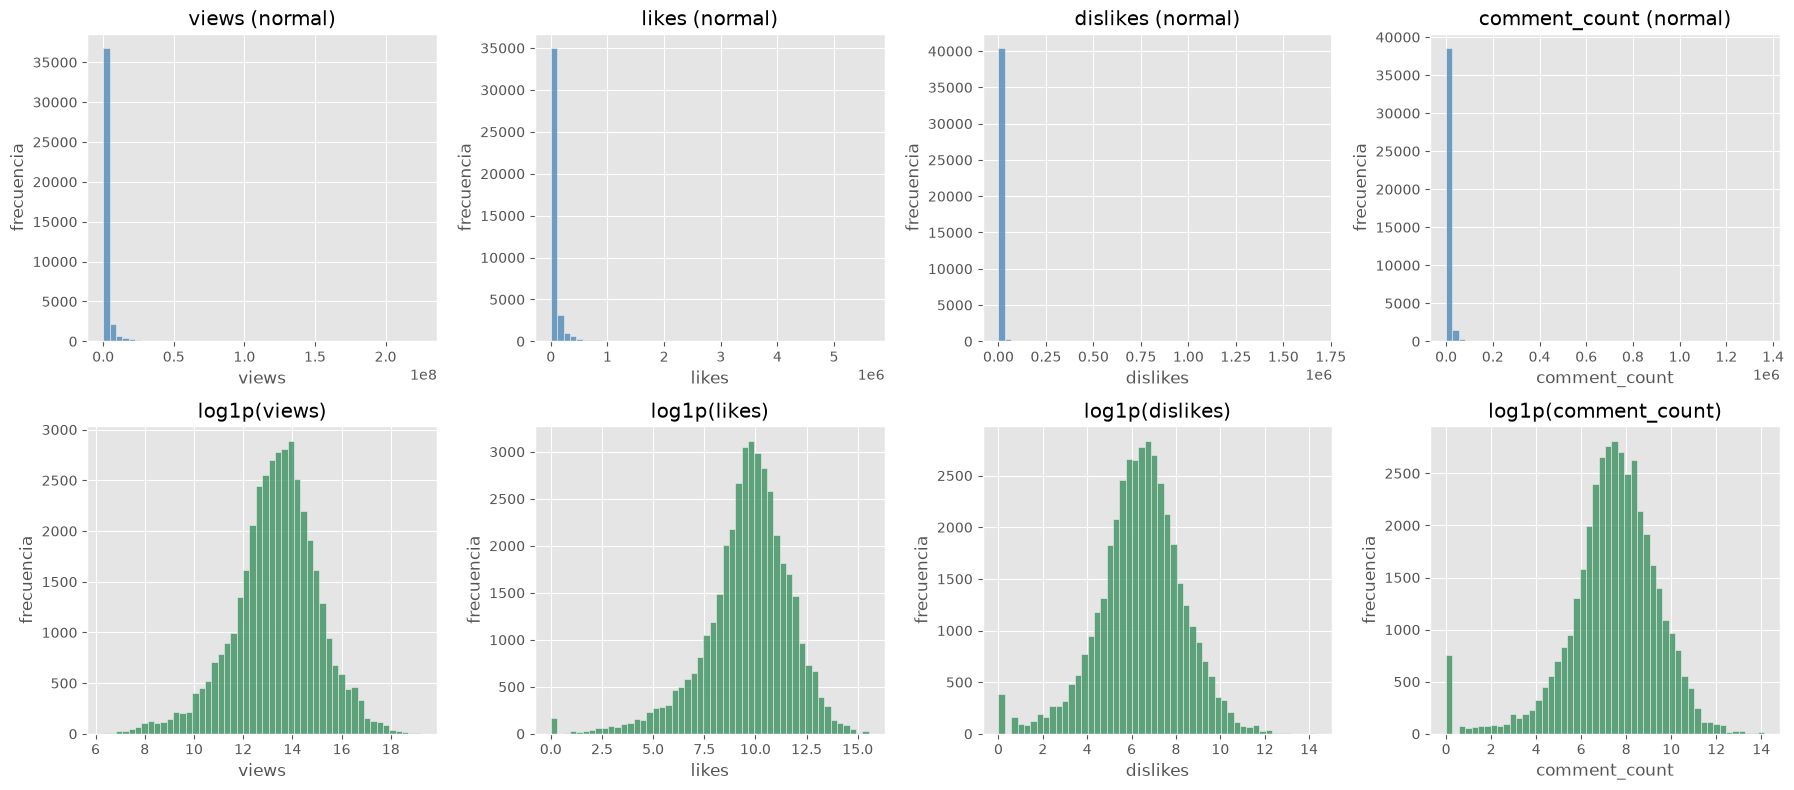

In [87]:
# Histogramas: escala normal (fila superior) vs log1p (fila inferior)
fig, axes = plt.subplots(2, len(num_cols), figsize=(18, 8))
for j, col in enumerate(num_cols):
    sns.histplot(df[col], bins=50, ax=axes[0, j], color="steelblue")
    axes[0, j].set_title(f"{col} (normal)")
    axes[0, j].set_ylabel("frecuencia")

    sns.histplot(np.log1p(df[col]), bins=50, ax=axes[1, j], color="seagreen")
    axes[1, j].set_title(f"log1p({col})")
    axes[1, j].set_ylabel("frecuencia")
plt.tight_layout()
plt.show()

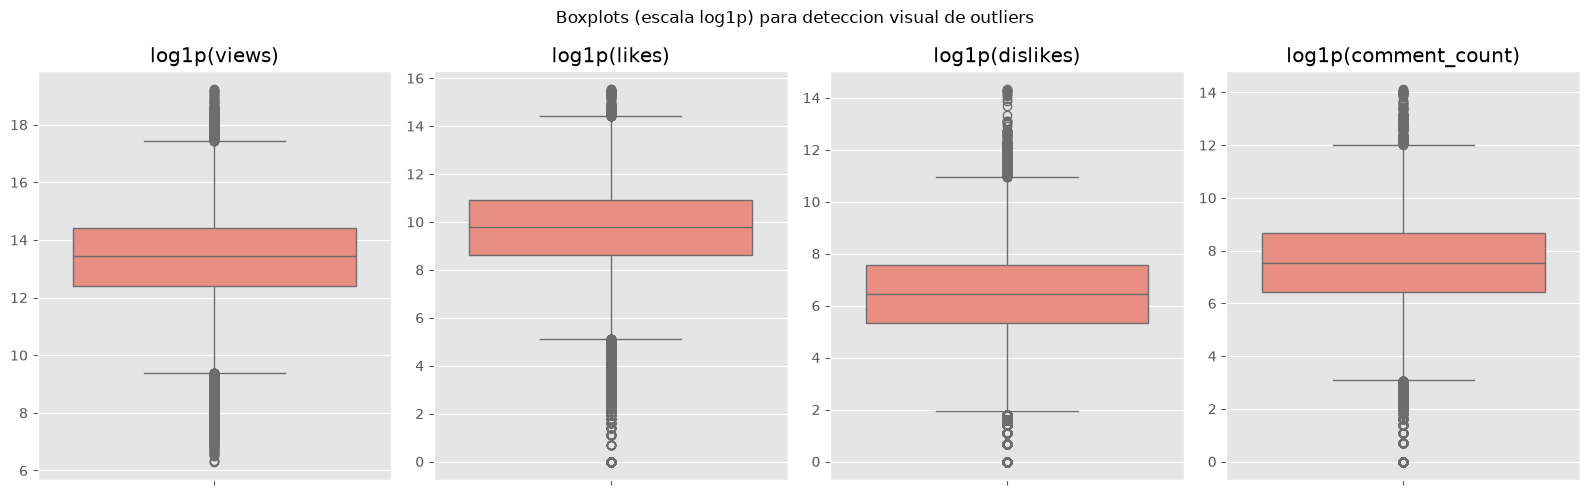

In [88]:
# Boxplots en escala logaritmica para visualizar outliers
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 5))
for j, col in enumerate(num_cols):
    sns.boxplot(y=np.log1p(df[col]), ax=axes[j], color="salmon")
    axes[j].set_title(f"log1p({col})")
    axes[j].set_ylabel("")
plt.suptitle("Boxplots (escala log1p) para deteccion visual de outliers")
plt.tight_layout()
plt.show()

In [89]:
# Deteccion de outliers por IQR y conteo de ceros
def resumen_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((serie < low) | (serie > high)).sum()
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "limite_inf": low, "limite_sup": high,
        "n_outliers": int(n_out),
        "%_outliers": round(n_out / len(serie) * 100, 2),
        "n_ceros": int((serie == 0).sum()),
    })

pd.DataFrame({c: resumen_iqr(df[c]) for c in num_cols}).T

,Q1,Q3,IQR,limite_inf,limite_sup,n_outliers,%_outliers,n_ceros
views,242329.0,1823157.0,1580828.0,-2128913.0,4194399.0,4499.0,10.99,0.0
likes,5424.0,55417.0,49993.0,-69565.5,130406.5,5136.0,12.54,172.0
dislikes,202.0,1938.0,1736.0,-2402.0,4542.0,5288.0,12.91,383.0
comment_count,614.0,5755.0,5141.0,-7097.5,13466.5,5089.0,12.43,760.0


## 6.5 Distribuciones univariadas (numéricas y categóricas)

Vista compacta para complementar lo anterior: una grilla de histogramas de las
variables numéricas (en escala `log1p`, por el sesgo) y gráficos de barras de las
principales variables categóricas (usando top-N para no saturar).

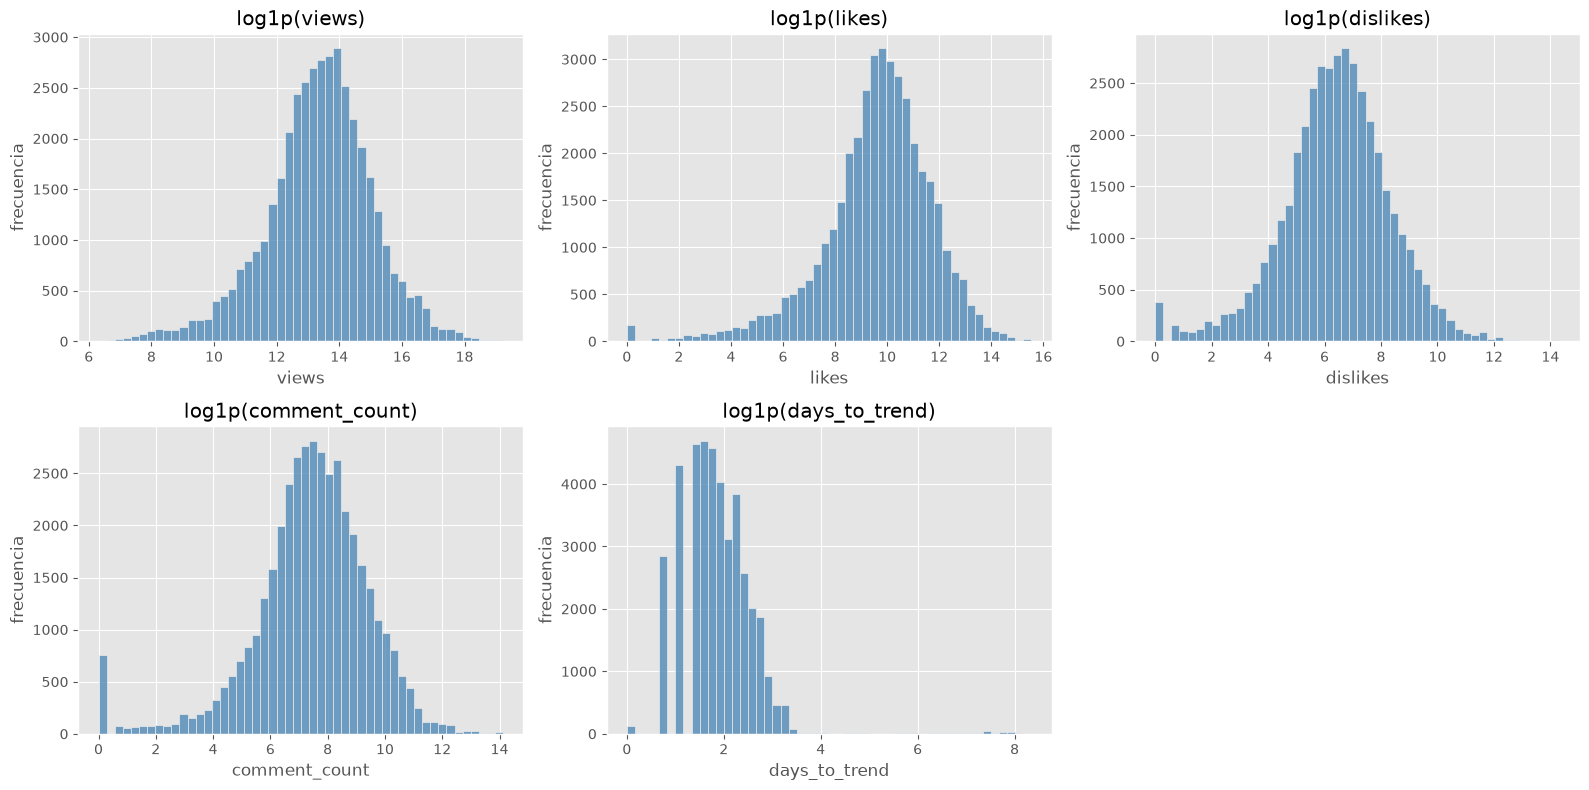

In [90]:
# days_to_trend (comparacion solo por fecha, como la correccion aplicada) para tenerlo disponible
_trend = pd.to_datetime(df["trending_date"], format="%y.%d.%m", errors="coerce")
_pub = pd.to_datetime(df["publish_time"], errors="coerce", utc=True).dt.tz_localize(None)
df["days_to_trend"] = (_trend.dt.normalize() - _pub.dt.normalize()).dt.days

# Histogramas de variables numericas (escala log1p por el sesgo), en una grilla compacta
num_vars = ["views", "likes", "dislikes", "comment_count", "days_to_trend"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_vars):
    serie = df[col].clip(lower=0)
    sns.histplot(np.log1p(serie), bins=50, ax=ax, color="steelblue")
    ax.set_title(f"log1p({col})")
    ax.set_ylabel("frecuencia")
axes.flat[-1].axis("off")  # celda sobrante
plt.tight_layout()
plt.show()

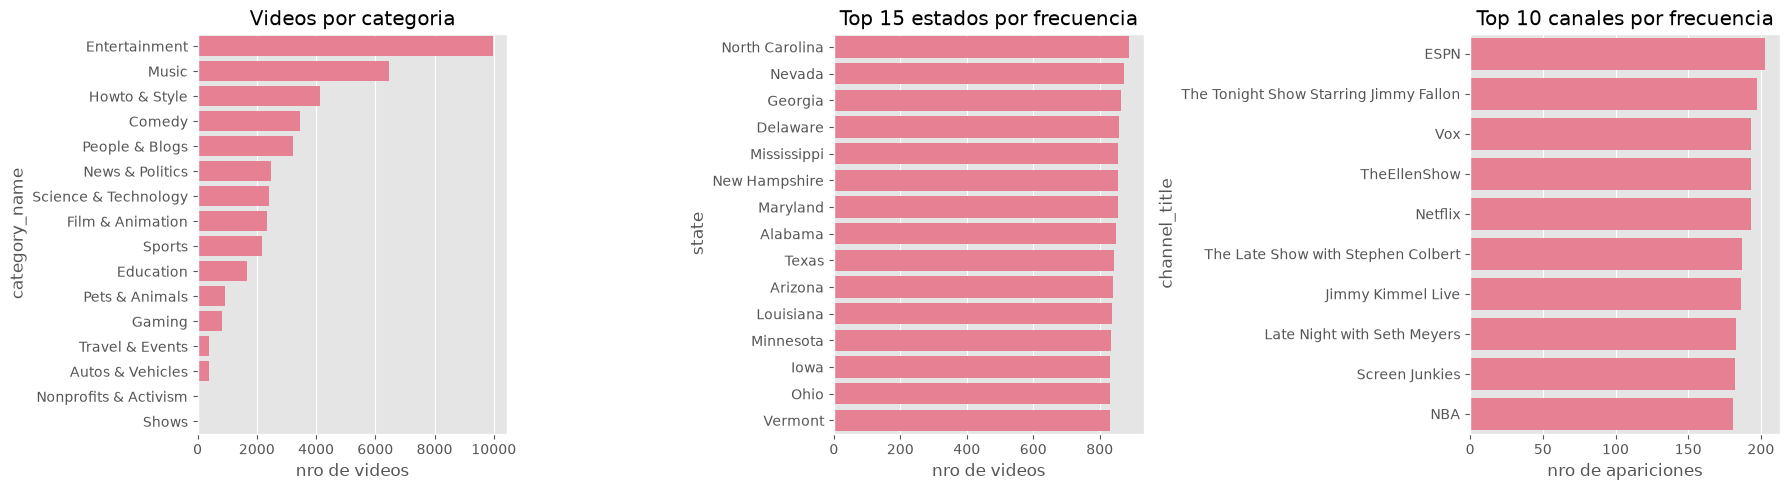

In [91]:
# Graficos de barras para variables categoricas (top-N para no saturar)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_counts = df["category_name"].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[0])
axes[0].set_title("Videos por categoria")
axes[0].set_xlabel("nro de videos")

state_counts = df["state"].value_counts().head(15)
sns.barplot(x=state_counts.values, y=state_counts.index, ax=axes[1])
axes[1].set_title("Top 15 estados por frecuencia")
axes[1].set_xlabel("nro de videos")

channel_counts = df["channel_title"].value_counts().head(10)
sns.barplot(x=channel_counts.values, y=channel_counts.index, ax=axes[2])
axes[2].set_title("Top 10 canales por frecuencia")
axes[2].set_xlabel("nro de apariciones")

plt.tight_layout()
plt.show()

## 7. Correlaciones

Matriz de correlación entre las métricas numéricas (sobre los valores `log1p` para
reducir el efecto del sesgo) y diagramas de dispersión de `views` frente a las demás
métricas. Esto anticipa la viabilidad de un modelo de regresión.

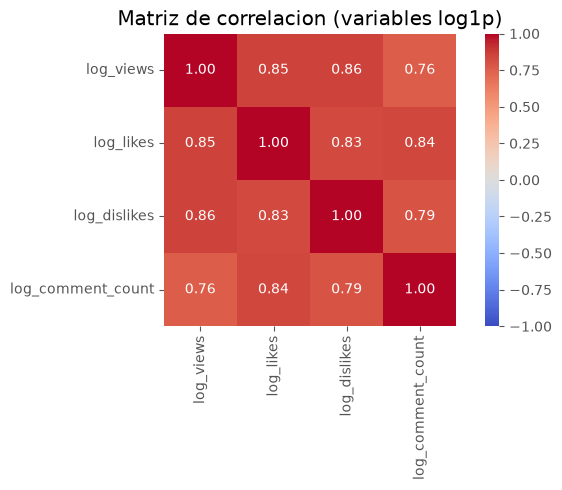

In [92]:
# Matriz de correlacion sobre las variables log-transformadas
log_df = np.log1p(df[num_cols]).add_prefix("log_")
corr = log_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlacion (variables log1p)")
plt.tight_layout()
plt.show()

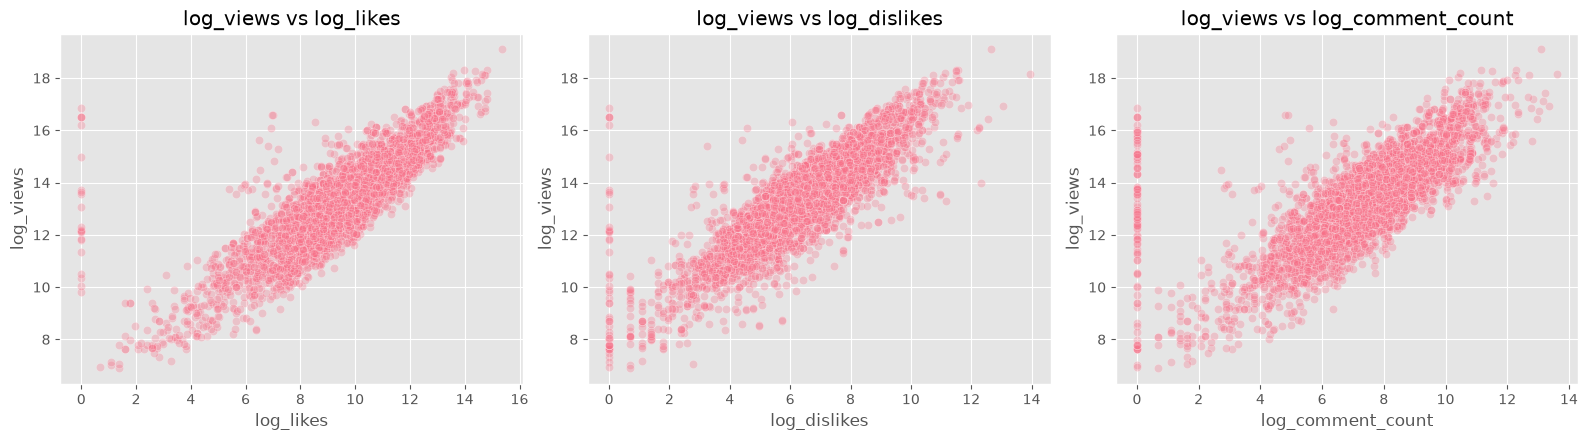

In [93]:
# Dispersion de log_views frente a las otras metricas (muestra para agilizar el ploteo)
muestra = log_df.sample(min(5000, len(log_df)), random_state=42)
otras = [c for c in log_df.columns if c != "log_views"]

fig, axes = plt.subplots(1, len(otras), figsize=(16, 4.5))
for ax, col in zip(axes, otras):
    sns.scatterplot(x=muestra[col], y=muestra["log_views"], alpha=0.3, ax=ax)
    ax.set_title(f"log_views vs {col}")
plt.tight_layout()
plt.show()

## 7.5 Variables que discriminan el target (`likes`)

Medimos qué variables **separan** mejor el comportamiento del target `likes`, dejando
de lado las limitaciones del dataset (se incluyen incluso variables con fuga potencial
—`views`, `dislikes`, `comment_count`— o de geografía aleatoria —`state`—, solo para
contrastar su poder discriminante):

- **Numéricas**: correlación de **Spearman** con `log_likes` (robusta a la asimetría).
- **Categóricas**: razón de correlación **eta² = SS_between / SS_total** (fracción de la
  varianza de `log_likes` explicada por la variable). Se espera que `state` salga ≈ 0
  (aleatoria) y `category_name` bastante mayor.

> Nota: esta sección mide separación del target sin filtrar por leakage/aleatoriedad;
> esos caveats se discuten aparte y condicionan qué variables entran realmente al modelo.

In [94]:
# Preparar target y features auxiliares
log_likes = np.log1p(df["likes"])
denom = df["views"].replace(0, np.nan)
df["dislike_view_ratio"] = (df["dislikes"] / denom).fillna(0)
df["comment_view_ratio"] = (df["comment_count"] / denom).fillna(0)

# Discriminacion de variables NUMERICAS: |Spearman| con log_likes
num_feats = ["views", "dislikes", "comment_count", "days_to_trend",
             "dislike_view_ratio", "comment_view_ratio"]
spearman = (
    pd.Series({c: df[c].corr(log_likes, method="spearman") for c in num_feats})
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
tabla_num = spearman.rename("spearman_vs_log_likes").to_frame()
tabla_num["|spearman|"] = tabla_num["spearman_vs_log_likes"].abs().round(3)
tabla_num.round(3)

,spearman_vs_log_likes,|spearman|
comment_count,0.878,0.878
views,0.863,0.863
dislikes,0.799,0.799
days_to_trend,0.249,0.249
comment_view_ratio,0.152,0.152
dislike_view_ratio,0.052,0.052


In [95]:
# Discriminacion de variables CATEGORICAS: razon de correlacion eta^2 con log_likes
def eta_squared(cat, y):
    d = pd.DataFrame({"c": cat.values, "y": y.values}).dropna()
    grand = d["y"].mean()
    ss_total = ((d["y"] - grand) ** 2).sum()
    if ss_total == 0:
        return np.nan
    ss_between = d.groupby("c")["y"].apply(lambda g: len(g) * (g.mean() - grand) ** 2).sum()
    return ss_between / ss_total

cat_feats = ["category_name", "state", "channel_title"]
tabla_cat = (
    pd.Series({c: eta_squared(df[c], log_likes) for c in cat_feats}, name="eta2_vs_log_likes")
    .sort_values(ascending=False)
    .round(4)
    .to_frame()
)
tabla_cat

,eta2_vs_log_likes
channel_title,0.8395
category_name,0.1533
state,0.0010


### 7.5.1 Agrupación de `category_name` por impacto (para one-hot)

`category_name` tiene 16 niveles: un one-hot directo genera ~15 dummies y `channel_title`
(2207 niveles) es inviable. Como alternativa, agrupamos las categorías en **4 niveles según
su impacto** en `log_likes`, lo que permite un one-hot compacto (3 dummies, referencia = `Bajo`)
sin perder casi poder explicativo. Abajo evidenciamos que los 4 grupos forman escalones
limpios y que el `eta²` apenas baja al pasar de 16 categorías a 4 grupos.

Esta agrupación es la que consume el notebook de limpieza (`limpieza.ipynb`) para construir
las variables `catgrupo_*`.

In [96]:
# Agrupacion de categorias en 4 niveles por impacto en log_likes
GRUPO_CATEGORIA = {
    "Music": "Alto", "Gaming": "Alto", "Comedy": "Alto",
    "Entertainment": "MedioAlto", "Howto & Style": "MedioAlto",
    "Film & Animation": "MedioAlto", "People & Blogs": "MedioAlto",
    "Education": "MedioAlto", "Science & Technology": "MedioAlto",
    "Pets & Animals": "MedioAlto", "Shows": "MedioAlto",
    "Sports": "MedioBajo", "Travel & Events": "MedioBajo",
    "News & Politics": "Bajo", "Autos & Vehicles": "Bajo",
    "Nonprofits & Activism": "Bajo",
}
ORDEN_GRUPOS = ["Bajo", "MedioBajo", "MedioAlto", "Alto"]

# Tabla de impacto por categoria (ordenada por media de log_likes)
tabla_impacto = (
    df.assign(_ll=log_likes)
      .groupby("category_name")
      .agg(n=("likes", "size"),
           mediana_likes=("likes", "median"),
           media_log_likes=("_ll", "mean"))
      .sort_values("media_log_likes", ascending=False)
)
tabla_impacto["grupo"] = tabla_impacto.index.map(GRUPO_CATEGORIA)
print("Impacto por categoria (ordenado por media log_likes):")
print(tabla_impacto.round(2))

# Comparacion de poder discriminante: 16 categorias vs 4 grupos
cat_grupo = pd.Series(
    pd.Categorical(df["category_name"].map(GRUPO_CATEGORIA), categories=ORDEN_GRUPOS, ordered=True)
)
eta_16 = eta_squared(df["category_name"], log_likes)
eta_4 = eta_squared(cat_grupo, log_likes)
print(f"\neta^2 con 16 categorias: {eta_16:.4f}")
print(f"eta^2 con 4 grupos     : {eta_4:.4f}  ({eta_4 / eta_16 * 100:.1f}% del original)")

Impacto por categoria (ordenado por media log_likes):
                          n  mediana_likes  media_log_likes      grupo
category_name                                                         
Music                  6472        62280.5            10.81       Alto
Gaming                  817        51057.0            10.54       Alto
Comedy                 3457        30214.0            10.15       Alto
Howto & Style          4146        21492.5             9.78  MedioAlto
Film & Animation       2345        25176.0             9.71  MedioAlto
People & Blogs         3210        19438.0             9.61  MedioAlto
Shows                    57        21537.0             9.50  MedioAlto
Education              1656        13508.5             9.47  MedioAlto
Entertainment          9964        16234.0             9.44  MedioAlto
Science & Technology   2401        16328.0             9.31  MedioAlto
Pets & Animals          920        14431.5             9.28  MedioAlto
Travel & Events        

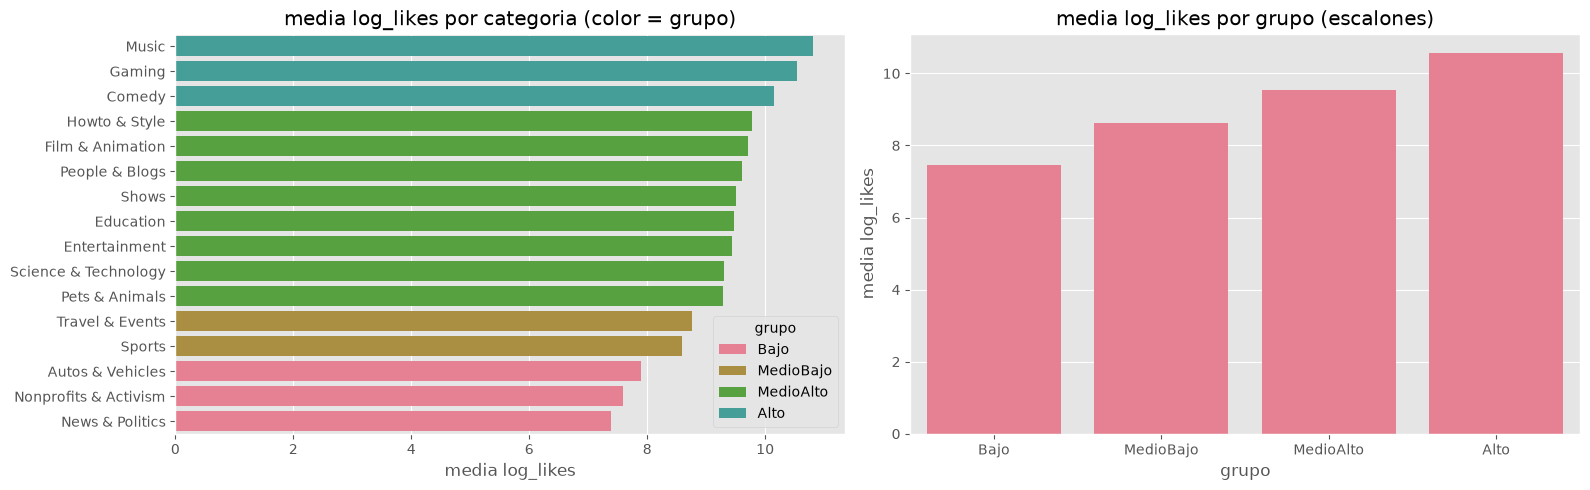

In [97]:
# Visual: escalones de impacto por categoria y por grupo
tp = tabla_impacto.reset_index()
medias_grupo = (
    pd.Series(log_likes.values, index=cat_grupo.values)
    .groupby(level=0).mean().reindex(ORDEN_GRUPOS)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=tp, x="media_log_likes", y="category_name",
            hue="grupo", hue_order=ORDEN_GRUPOS, dodge=False, ax=axes[0])
axes[0].set_title("media log_likes por categoria (color = grupo)")
axes[0].set_xlabel("media log_likes")
axes[0].set_ylabel("")
axes[0].legend(title="grupo", loc="lower right")

sns.barplot(x=medias_grupo.index, y=medias_grupo.values, order=ORDEN_GRUPOS, ax=axes[1])
axes[1].set_title("media log_likes por grupo (escalones)")
axes[1].set_xlabel("grupo")
axes[1].set_ylabel("media log_likes")

plt.tight_layout()
plt.show()

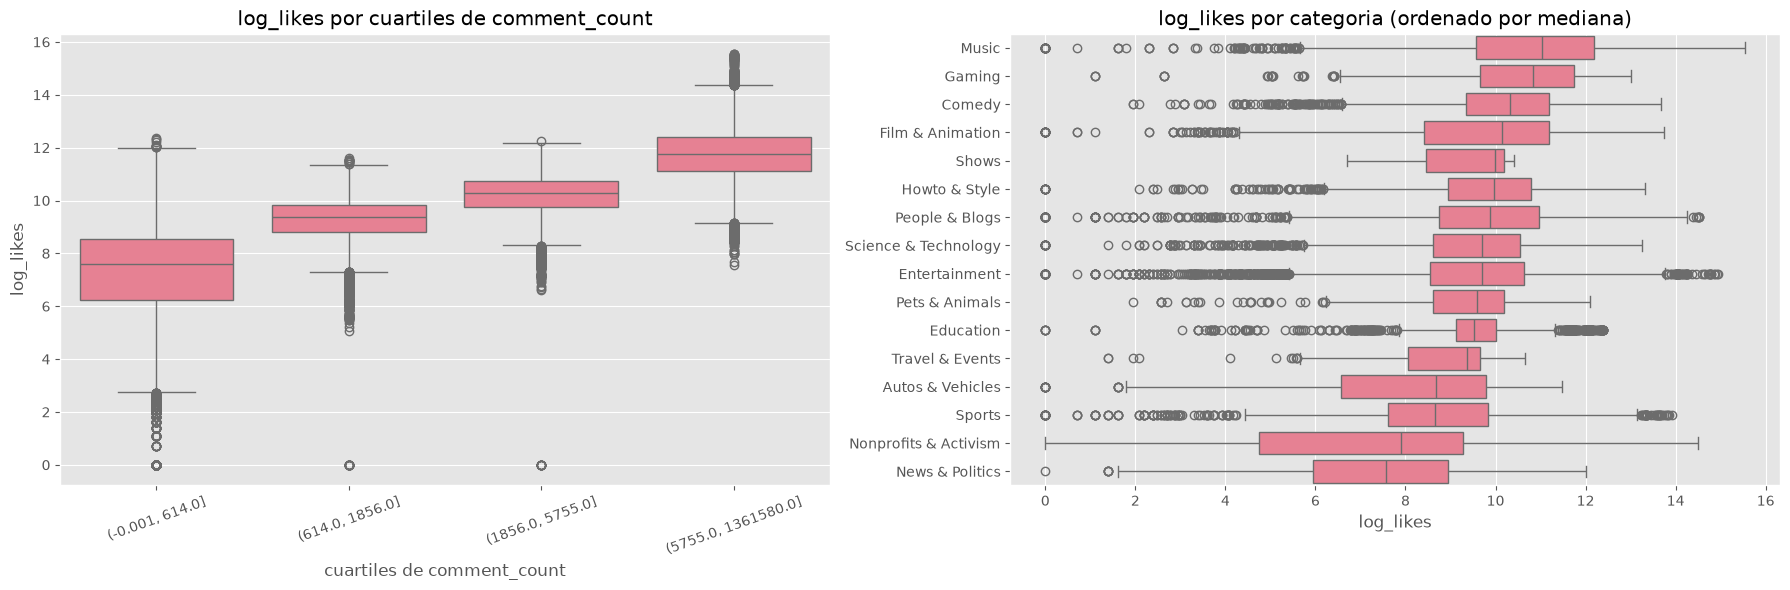

In [98]:
# Visual: como se separa el target segun las variables mas discriminantes
top_num = spearman.abs().idxmax()  # numerica mas discriminante

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (a) log_likes por cuartiles de la numerica mas discriminante
cuartiles = pd.qcut(df[top_num], q=4, duplicates="drop")
sns.boxplot(x=cuartiles, y=log_likes, ax=axes[0])
axes[0].set_title(f"log_likes por cuartiles de {top_num}")
axes[0].set_xlabel(f"cuartiles de {top_num}")
axes[0].set_ylabel("log_likes")
axes[0].tick_params(axis="x", rotation=20)

# (b) log_likes por categoria (ordenado por mediana)
orden = df.groupby("category_name")["likes"].median().sort_values(ascending=False).index
sns.boxplot(x=log_likes, y=df["category_name"], order=orden, ax=axes[1])
axes[1].set_title("log_likes por categoria (ordenado por mediana)")
axes[1].set_xlabel("log_likes")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 8. Temporalidad

Parseamos `trending_date` (formato `YY.DD.MM`) y `publish_time` para conocer el rango
temporal cubierto y construir `days_to_trend` (días entre la publicación y la entrada
en tendencia). Los valores **negativos** de `days_to_trend` son inconsistencias
(tendencia antes de publicar) que se marcan para la limpieza.

In [99]:
# Parseo de fechas (sin modificar el df original; usamos variables auxiliares)
trending_dt = pd.to_datetime(df["trending_date"], format="%y.%d.%m", errors="coerce").dt.date
publish_dt = pd.to_datetime(df["publish_time"], errors="coerce", utc=True).dt.tz_localize(None).dt.date

print("Rango trending_date:", trending_dt.min(), "->", trending_dt.max())
print("Rango publish_time :", publish_dt.min(), "->", publish_dt.max())
print("Fechas de tendencia no parseables:", int(trending_dt.isna().sum()))
print("Fechas de publicacion no parseables:", int(publish_dt.isna().sum()))

Rango trending_date: 2017-11-14 -> 2018-06-14
Rango publish_time : 2006-07-23 -> 2018-06-14
Fechas de tendencia no parseables: 0
Fechas de publicacion no parseables: 0


days_to_trend -> min: 0, mediana: 5.0, max: 4215
Registros con days_to_trend NEGATIVO (inconsistentes): 0


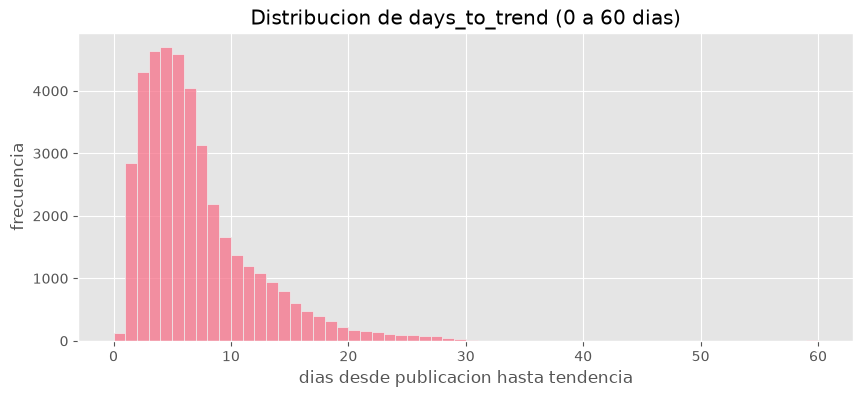

In [100]:
# days_to_trend y deteccion de valores negativos (inconsistencias)
days_to_trend = (trending_dt - publish_dt).apply(lambda x: x.days if pd.notnull(x) else np.nan)
n_negativos = int((days_to_trend < 0).sum())

print(f"days_to_trend -> min: {days_to_trend.min()}, mediana: {days_to_trend.median()}, max: {days_to_trend.max()}")
print(f"Registros con days_to_trend NEGATIVO (inconsistentes): {n_negativos}")

plt.figure(figsize=(10, 4))
sns.histplot(days_to_trend[(days_to_trend >= 0) & (days_to_trend <= 60)], bins=60)
plt.title("Distribucion de days_to_trend (0 a 60 dias)")
plt.xlabel("dias desde publicacion hasta tendencia")
plt.ylabel("frecuencia")
plt.show()

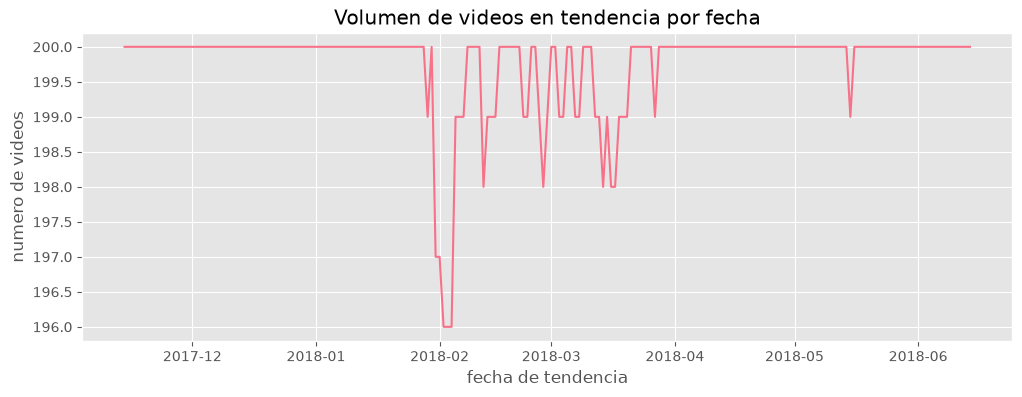

In [101]:
# Volumen de videos en tendencia a lo largo del tiempo
volumen = trending_dt.value_counts().sort_index()

plt.figure(figsize=(12, 4))
volumen.plot()
plt.title("Volumen de videos en tendencia por fecha")
plt.xlabel("fecha de tendencia")
plt.ylabel("numero de videos")
plt.show()

## 9. Validación de reglas de negocio

Implementamos como código las reglas esbozadas en `scripts/eda.py`. Cada regla define
una condición que las filas *válidas* deben cumplir; contamos las **violaciones**:

1. `likes <= views` y `dislikes <= views` — no puede haber más reacciones que vistas.
2. `trending_date >= publish_time` — un video no puede ser tendencia antes de publicarse.
3. `comment_count <= views` — no puede haber más comentarios que vistas.
4. `comments_disabled == True` implica `comment_count == 0`.
5. `ratings_disabled == True` implica `likes == 0` y `dislikes == 0`.

In [102]:
# Normalizamos las columnas booleanas por si vienen como texto ("True"/"False")
def a_bool(serie):
    if serie.dtype == bool:
        return serie
    return serie.astype(str).str.strip().str.lower().isin(["true", "1", "yes"])

comments_disabled = a_bool(df["comments_disabled"])
ratings_disabled = a_bool(df["ratings_disabled"])

# Cada entrada: nombre de la regla -> mascara booleana de VIOLACIONES
violaciones = {
    "R1a: likes > views": df["likes"] > df["views"],
    "R1b: dislikes > views": df["dislikes"] > df["views"],
    "R2: trending < publish": days_to_trend < 0,
    "R3: comment_count > views": df["comment_count"] > df["views"],
    "R4: comments_disabled pero comment_count>0": comments_disabled & (df["comment_count"] > 0),
    "R5: ratings_disabled pero likes/dislikes>0": ratings_disabled & ((df["likes"] > 0) | (df["dislikes"] > 0)),
}

resumen_reglas = pd.DataFrame({
    "n_violaciones": {k: int(v.sum()) for k, v in violaciones.items()},
})
resumen_reglas["%_violaciones"] = (resumen_reglas["n_violaciones"] / len(df) * 100).round(3)
resumen_reglas

,n_violaciones,%_violaciones
R1a: likes > views,0,0.0
R1b: dislikes > views,0,0.0
R2: trending < publish,0,0.0
R3: comment_count > views,0,0.0
R4: comments_disabled pero comment_count>0,0,0.0
R5: ratings_disabled pero likes/dislikes>0,0,0.0


In [103]:
# Filas que violan AL MENOS una regla (candidatas a revision/limpieza)
mascara_cualquiera = pd.concat(violaciones.values(), axis=1).any(axis=1)
print(f"Filas que violan al menos una regla: {int(mascara_cualquiera.sum())} "
      f"({mascara_cualquiera.mean() * 100:.3f}% del total)")

cols_muestra = ["video_id", "views", "likes", "dislikes", "comment_count",
                "comments_disabled", "ratings_disabled", "trending_date", "publish_time"]
df.loc[mascara_cualquiera, cols_muestra].head(10)

Filas que violan al menos una regla: 0 (0.000% del total)


,video_id,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,trending_date,publish_time


In [104]:
# Resumen numerico consolidado (para el checklist de limpieza)
print("=== RESUMEN PARA LA LIMPIEZA ===")
print(f"Filas totales: {len(df):,}")
print(f"Duplicados exactos: {dup_exactos}")
print(f"Duplicados (video_id, trending_date): {dup_video_fecha}")
print(f"Columnas con nulos: {int((df.isnull().sum() > 0).sum())}")
print(f"days_to_trend negativos: {n_negativos}")
print(f"Filas que violan alguna regla de negocio: {int(mascara_cualquiera.sum())}")
print("\nNulos por columna (solo > 0):")
print(tabla_nulos[tabla_nulos['n_nulos'] > 0].to_string())

=== RESUMEN PARA LA LIMPIEZA ===
Filas totales: 40,949
Duplicados exactos: 1
Duplicados (video_id, trending_date): 50
Columnas con nulos: 1
days_to_trend negativos: 0
Filas que violan alguna regla de negocio: 0

Nulos por columna (solo > 0):
             n_nulos  %_nulos
description      570     1.39


## 10. Resumen de hallazgos para la limpieza

A partir de esta exploración, la fase de **limpieza** debería considerar (ajustar según
los números obtenidos al ejecutar el notebook):

- **Duplicados**: eliminar duplicados exactos y revisar los duplicados por
  `(video_id, trending_date)` si existen, pues estos representan duplicados reales al solo diferenciarse en "state", el cual fue introducido de forma aleatoria. Mantener los duplicados por `video_id` que
  correspondan a días de tendencia distintos (comportamiento esperado).
- **Nulos**: tratar las columnas con nulos (p. ej. `description`), decidiendo entre
  imputar (texto vacío) o dejar el nulo según el uso posterior.
- **Outliers y sesgo**: las métricas de engagement están muy sesgadas a la derecha; se
  justifica aplicar `log1p` para el modelado en lugar de eliminar los valores extremos
  (son videos virales reales, no errores).
- **Consistencia temporal**: descartar o corregir los registros con `days_to_trend`
  negativo. Crear `days_to_trend` como variable derivada.
- **Reglas de negocio**: revisar las filas que violan alguna regla (likes/dislikes/
  comentarios mayores que las vistas, o flags `*_disabled` inconsistentes con sus
  conteos) y decidir si se corrigen o se eliminan.
- **Columnas**: evaluar la utilidad de columnas de alta cardinalidad o poco
  informativas para el análisis (`thumbnail_link`, `geometry`, `tags`).

> Siguiente paso: implementar estas decisiones en la fase de preparación/limpieza
> (por ejemplo en `scripts/limpieza.py` o en la sección correspondiente del notebook
> principal).